# 🌿 PlantVillage 農作物病蟲害影像辨識

**組別：第 10 組**

## 專題目標
讓農民不依賴專家,透過手機拍攝葉片影像即可即時辨識病蟲害,降低農作損失與經濟風險。

## 方法摘要
- **資料集**:PlantVillage Dataset(20,639 張葉片影像,涵蓋 3 種作物的 15 個類別)
- **模型**:MobileNetV2 預訓練模型 + 兩階段訓練(特徵萃取 + Fine-tuning)
- **切分**:70% 訓練 / 30% 驗證,搭配資料增強
- **輸出**:病害類別 + 信心程度

## 開發環境
Kaggle Notebook + GPU T4 x2

## 1️⃣ 探索資料集結構

自動偵測 PlantVillage 資料夾位置,並統計各類別影像數量。

> **觀察**:資料集存在類別不平衡問題,最少 152 張(Potato_healthy)、最多 3209 張(Tomato_YellowLeaf_Curl_Virus),差距達 20 倍。

In [26]:
import os

# 自動找出 PlantVillage 資料夾位置
for root, dirs, files in os.walk('/kaggle/input'):
    if 'PlantVillage' in dirs:
        data_dir = os.path.join(root, 'PlantVillage')
        print(f"✅ 找到資料夾:{data_dir}\n")
        break

# 列出所有類別與張數
classes = sorted(os.listdir(data_dir))
print(f"類別數:{len(classes)}\n")
total = 0
for c in classes:
    n = len(os.listdir(os.path.join(data_dir, c)))
    total += n
    print(f"  {c:<45} {n:>5} 張")
print(f"\n總計:{total} 張圖")

✅ 找到資料夾:/kaggle/input/datasets/emmarex/plantdisease/PlantVillage

類別數:15

  Pepper__bell___Bacterial_spot                   997 張
  Pepper__bell___healthy                         1478 張
  Potato___Early_blight                          1000 張
  Potato___Late_blight                           1000 張
  Potato___healthy                                152 張
  Tomato_Bacterial_spot                          2127 張
  Tomato_Early_blight                            1000 張
  Tomato_Late_blight                             1909 張
  Tomato_Leaf_Mold                                952 張
  Tomato_Septoria_leaf_spot                      1771 張
  Tomato_Spider_mites_Two_spotted_spider_mite    1676 張
  Tomato__Target_Spot                            1404 張
  Tomato__Tomato_YellowLeaf__Curl_Virus          3209 張
  Tomato__Tomato_mosaic_virus                     373 張
  Tomato_healthy                                 1591 張

總計:20639 張圖


## 2️⃣ 資料管線:70/30 切分 + 資料增強

依照規劃,將資料切分為訓練集 70% 與驗證集 30%。對訓練集套用資料增強
(旋轉、翻轉、縮放),模擬田間自然光下不同角度的拍攝條件,提升模型泛化能力。

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1
)

train_ds = datagen.flow_from_directory(
    data_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_ds = datagen.flow_from_directory(
    data_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

num_classes = len(train_ds.class_indices)
class_names = list(train_ds.class_indices.keys())

print(f"\n類別數:{num_classes}")
print(f"訓練集:{train_ds.samples} 張")
print(f"驗證集:{val_ds.samples} 張")

Found 14452 images belonging to 15 classes.
Found 6186 images belonging to 15 classes.

類別數:15
訓練集:14452 張
驗證集:6186 張


## 3️⃣ 建立模型:遷移學習 (Transfer Learning)

採用 MobileNetV2 作為特徵萃取骨幹(Backbone),凍結預訓練權重,
僅訓練自訂分類頭部。MobileNetV2 參數量僅 3.5M,適合未來部署於手機端,
契合本專題「農民田間使用」之應用場景。

### 為什麼用 Softmax 輸出
Softmax 將原始輸出轉換為機率分布(總和為 1),直接對應規劃中
「提供模型信心程度以輔助判斷可靠性」的需求。

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False    # 凍結 backbone,只訓練分類頭

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4️⃣ 第一階段訓練:特徵萃取

凍結 MobileNetV2,僅訓練分類頭部 10 個 epoch。
此階段讓模型學會「如何用預訓練特徵分辨 15 個病害類別」。

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 114s 253ms/step - accuracy: 0.8882 - loss: 0.3238 - val_accuracy: 0.8969 - val_loss: 0.3038
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 102s 225ms/step - accuracy: 0.8868 - loss: 0.3189 - val_accuracy: 0.8927 - val_loss: 0.3138
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 107s 237ms/step - accuracy: 0.8910 - loss: 0.3185 - val_accuracy: 0.8902 - val_loss: 0.3112
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.8956 - loss: 0.3092 - val_accuracy: 0.8944 - val_loss: 0.3140
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 103s 228ms/step - accuracy: 0.8970 - loss: 0.2986 - val_accuracy: 0.9004 - val_loss: 0.2925
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 108s 238ms/step - accuracy: 0.9077 - loss: 0.2778 - val_accuracy: 0.9032 - val_loss: 0.2911
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 103s 227ms/step - accuracy: 0.9016 - loss: 0.2965 - val_accuracy: 0.9061 - val_loss: 0.2705
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 103s 227ms/step - accuracy: 0.9038 -

## 5️⃣ 第二階段訓練:Fine-tuning

解凍 MobileNetV2 上層 30 個區塊,以較小的學習率(1e-5)微調,
使模型針對葉片病害領域進行特化調適。

此為業界標準的兩階段訓練策略,可在不破壞預訓練權重的前提下,
進一步提升模型於目標領域的表現。

In [33]:
from tensorflow.keras.optimizers import Adam

# 解凍 backbone 上層
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

# 重新編譯(更小的學習率)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune 10 個 epoch
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 139s 274ms/step - accuracy: 0.9435 - loss: 0.1643 - val_accuracy: 0.9475 - val_loss: 0.1696
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 111s 246ms/step - accuracy: 0.9461 - loss: 0.1545 - val_accuracy: 0.9475 - val_loss: 0.1620
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 109s 240ms/step - accuracy: 0.9487 - loss: 0.1447 - val_accuracy: 0.9507 - val_loss: 0.1670
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 108s 239ms/step - accuracy: 0.9474 - loss: 0.1516 - val_accuracy: 0.9457 - val_loss: 0.1676
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 102s 227ms/step - accuracy: 0.9519 - loss: 0.1405 - val_accuracy: 0.9504 - val_loss: 0.1586
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 102s 225ms/step - accuracy: 0.9549 - loss: 0.1339 - val_accuracy: 0.9552 - val_loss: 0.1505
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 105s 232ms/step - accuracy: 0.9599 - loss: 0.1169 - val_accuracy: 0.9539 - val_loss: 0.1486
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 105s 233ms/step - accuracy: 0.9531 -

## 6️⃣ 訓練曲線分析

繪製兩階段訓練的準確率與損失變化,
評估模型是否持續學習以及是否有過擬合徵兆。

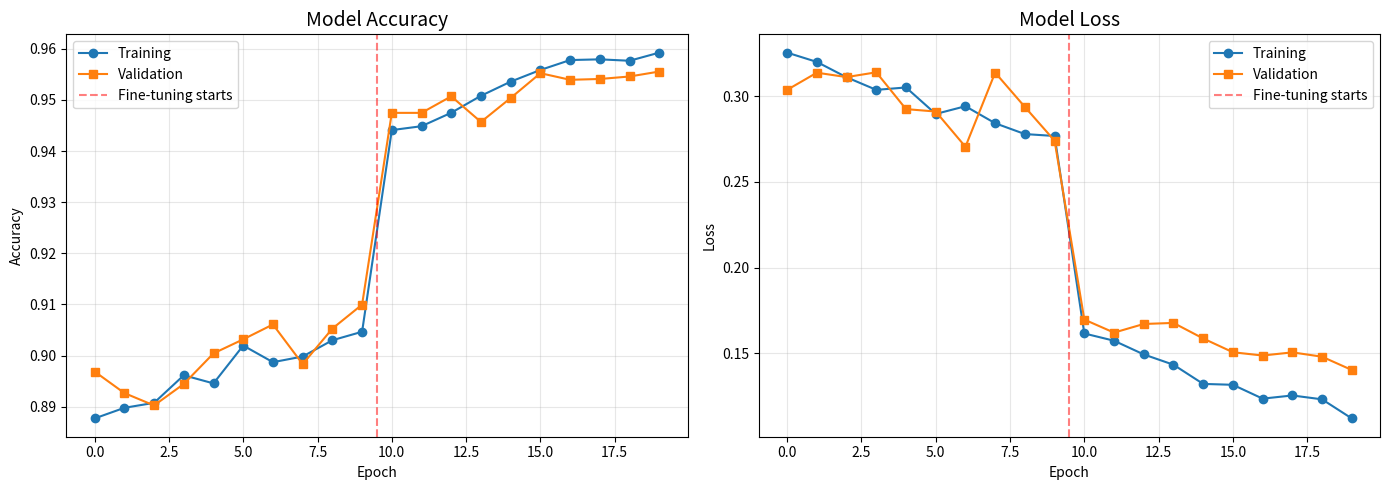

In [35]:
import matplotlib.pyplot as plt

# 合併兩階段訓練紀錄
acc      = history.history['accuracy']      + history_ft.history['accuracy']
val_acc  = history.history['val_accuracy']  + history_ft.history['val_accuracy']
loss     = history.history['loss']          + history_ft.history['loss']
val_loss = history.history['val_loss']      + history_ft.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label='Training', marker='o')
axes[0].plot(val_acc, label='Validation', marker='s')
axes[0].axvline(x=9.5, color='red', linestyle='--', alpha=0.5, label='Fine-tuning starts')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss, label='Training', marker='o')
axes[1].plot(val_loss, label='Validation', marker='s')
axes[1].axvline(x=9.5, color='red', linestyle='--', alpha=0.5, label='Fine-tuning starts')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()